# 03 — Retrieval Comparison

Compare dense, sparse, hybrid, and reranked retrieval on real AI Act queries.

**What this notebook covers:**
- Qualitative comparison: dense vs sparse vs hybrid vs reranked
- The Complice use case — fil rouge through the project
- Query categories: semantic, exact reference, cross-domain
- Dense/sparse overlap analysis
- Building intuition for the RAGAS test dataset (notebook 04)

**Cost:** ~1 Mistral embed call per query (~$0.0001 each — negligible)

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path('..').resolve()))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

from src.retrieval.reranker import RetrievalPipeline

print('Loading pipeline...')
pipeline = RetrievalPipeline.from_env(rerank_candidates=10)
print('✅ Pipeline ready (cross-encoder loads on first query)')

Loading pipeline...
✅ Pipeline ready (cross-encoder loads on first query)


## 1. Helper functions

In [2]:
def compare_retrieval(query, top_k=4, **kwargs):
    """Run full retrieval breakdown and display results side by side."""
    bd = pipeline.retrieve_for_evaluation(query, top_k=top_k, **kwargs)

    print(f'QUERY: {query}')
    print(f'Overlap (dense ∩ sparse): {bd["overlap"]} chunks')
    print()

    methods = [
        ('RERANKED  (final output)', bd['reranked'], 'score'),
        ('HYBRID    (pre-rerank)',   bd['hybrid'],   'rrf'),
        ('DENSE     (semantic)',     bd['dense_only'], 'cos'),
        ('SPARSE    (BM25)',         bd['sparse_only'], 'bm25'),
    ]

    for label, results, score_label in methods:
        print(f'  {label}:')
        if not results:
            print('    (no results)')
        for i, r in enumerate(results, 1):
            ref = r.display_reference or r.chunk_id
            print(f'    [{i}] {score_label}={r.score:.4f} | {ref}')
            print(f'         {r.text[:120].strip()}...')
        print()

    return bd

def show_top_result(query, top_k=1, **kwargs):
    """Show only the top reranked result with full text."""
    results = pipeline.retrieve(query, top_k=top_k, **kwargs)
    if not results:
        print('No results.')
        return
    r = results[0]
    print(f'QUERY: {query}')
    print(f'TOP RESULT: {r.display_reference} (score={r.score:.4f})')
    print('='*65)
    print(r.context_header)
    print()
    print(r.text[:600])
    print()
    print(f'Risk tiers: {r.risk_tier_relevance} | Deadline: {r.date_application}')
    print(f'Cross-refs: {r.cross_references[:5]}')

## 2. The Complice use case

Our fil rouge: a RAG-based conversational assistant for young adults with autism built on OpenAI.

In [4]:
bd = compare_retrieval(
    'Is a conversational assistant for young people with autism a high-risk AI system?',
    top_k=4
)

QUERY: Is a conversational assistant for young people with autism a high-risk AI system?
Overlap (dense ∩ sparse): 2 chunks

  RERANKED  (final output):
    [1] score=-1.9256 | Article 14(4) — Human oversight | HIGH-RISK AI SYSTEMS
         4.
For the purpose of implementing paragraphs 1, 2 and 3, the high-risk AI system shall be provided to the deployer in...
    [2] score=-2.4194 | Article 9(9) — Risk management system | HIGH-RISK AI SYSTEMS
         9.
When implementing the risk management system as provided for in paragraphs 1 to 7, providers shall give 
consideratio...
    [3] score=-2.5624 | Article 6(3) — Classification rules for high-risk AI systems | HIGH-RISK AI SYSTEMS
         3.
By derogation from paragraph 2, an AI system referred to in Annex III shall not be considered to be high-risk where i...
    [4] score=-3.1983 | Article 6(1) — Classification rules for high-risk AI systems | HIGH-RISK AI SYSTEMS
         1.
Irrespective of whether an AI system is placed on the mark

In [5]:
# Transparency obligations — directly applicable to Complice
show_top_result(
    'transparency obligations for AI systems interacting with natural persons',
    top_k=1
)

QUERY: transparency obligations for AI systems interacting with natural persons
TOP RESULT: Article 50(1) — Transparency obligations for providers and deployers of certain AI systems | TRANSPARENCY OBLIGATIONS FOR PROVIDERS AND DEPLOYERS OF CERTAIN AI SYSTEMS (score=9.8217)
[Chapter IV — TRANSPARENCY OBLIGATIONS FOR PROVIDERS AND DEPLOYERS OF CERTAIN AI SYSTEMS]
[Article 50 — Transparency obligations for providers and deployers of certain AI systems]
[Article 50, paragraph 1]

1.
Providers shall ensure that AI systems intended to interact directly with natural persons are designed and developed in 
such a way that the natural persons concerned are informed that they are interacting with an AI system, unless this is 
obvious from the point of view of a natural person who is reasonably well-informed, observant and circumspect, taking 
into account the circumstances and the context of use. This obligation shall not apply to AI systems authorised by law to 
detect, prevent, investigate or 

In [6]:
# Filtered retrieval — only high-risk chunks
print('FILTERED QUERY — high-risk systems only:')
bd_filtered = compare_retrieval(
    'education and training AI system obligations',
    top_k=3,
    risk_tiers=['high_risk']
)

FILTERED QUERY — high-risk systems only:
QUERY: education and training AI system obligations
Overlap (dense ∩ sparse): 2 chunks

  RERANKED  (final output):
    [1] score=4.9862 | Article 113(3) — Entry into force and application | FINAL PROVISIONS
         3.
Education and vocational training:
(a) AI systems intended to be used to determine access or admission or to assign n...
    [2] score=4.3709 | Article 26(2) — Obligations of deployers of high-risk AI systems | HIGH-RISK AI SYSTEMS
         2.
Deployers shall assign human oversight to natural persons who have the necessary competence, training and 
authority,...
    [3] score=3.2255 | Article 4 — AI literacy | GENERAL PROVISIONS
         Article 4
AI literacy
Providers and deployers of AI systems shall take measures to ensure, to their best extent, a suffi...

  HYBRID    (pre-rerank):
    [1] rrf=0.0323 | Article 113(3) — Entry into force and application | FINAL PROVISIONS
         3.
Education and vocational training:
(a) AI sy

## 3. Dense vs sparse — where each excels

### Understanding the Scoring Systems

Each retrieval method uses a different scoring mechanism:

- **Dense (cos)**: Cosine similarity 0.0-1.0 (higher = better semantic match)
- **Sparse (bm25)**: Best Match 25, 0.0-∞ (higher = better keyword relevance) 
- **Hybrid (rrf)**: Reciprocal Rank Fusion ~0.0-0.03 (tiny numbers, higher = better combined evidence)
- **Reranked (score)**: Cross-encoder relevance -∞ to +∞ (higher = better query-document relevance)

The following tests demonstrate where each method excels:

In [7]:
# Semantic query — dense should win
print('--- SEMANTIC QUERY (dense should excel) ---')
bd1 = compare_retrieval(
    'What protections exist for fundamental rights when AI is deployed?',
    top_k=3
)

--- SEMANTIC QUERY (dense should excel) ---
QUERY: What protections exist for fundamental rights when AI is deployed?
Overlap (dense ∩ sparse): 2 chunks

  RERANKED  (final output):
    [1] score=3.6532 | Article 27(2) — Fundamental rights impact assessment for high-risk AI systems | HIGH-RISK AI SYSTEMS
         2.
The obligation laid down in paragraph 1 applies to the first use of the high-risk AI system. The deployer may, in 
si...
    [2] score=3.4268 | Article 86(1) — Right to explanation of individual decision-making | POST-MARKET MONITORING, INFORMATION SHARING AND MARKET SURVEILLANCE
         1.
Any affected person subject to a decision which is taken by the deployer on the basis of the output from a high-risk...
    [3] score=3.0597 | Article 27(3) — Fundamental rights impact assessment for high-risk AI systems | HIGH-RISK AI SYSTEMS
         3.
Once the assessment referred to in paragraph 1 of this Article has been performed, the deployer shall notify the 
mar...

  HYBRID   

In [8]:
# Exact reference — sparse should win
print('--- EXACT REFERENCE (sparse should excel) ---')
bd2 = compare_retrieval(
    'Article 9 paragraph 4 risk management measures',
    top_k=3
)

--- EXACT REFERENCE (sparse should excel) ---
QUERY: Article 9 paragraph 4 risk management measures
Overlap (dense ∩ sparse): 10 chunks

  RERANKED  (final output):
    [1] score=9.5720 | Article 9(4) — Risk management system | HIGH-RISK AI SYSTEMS
         4.
The risk management measures referred to in paragraph 2, point (d), shall give due consideration to the effects and...
    [2] score=7.9029 | Article 9(5) — Risk management system | HIGH-RISK AI SYSTEMS
         5.
The risk management measures referred to in paragraph 2, point (d), shall be such that the relevant residual risk 
as...
    [3] score=6.8015 | Article 9 — Risk management system | HIGH-RISK AI SYSTEMS
         Article 9
Risk management system
1.
A risk management system shall be established, implemented, documented and maintaine...

  HYBRID    (pre-rerank):
    [1] rrf=0.0320 | Article 9(4) — Risk management system | HIGH-RISK AI SYSTEMS
         4.
The risk management measures referred to in paragraph 2, point (d), 

In [9]:
# Prohibited practices — specific legal term
print('--- PROHIBITED PRACTICES ---')
bd3 = compare_retrieval(
    'subliminal manipulation prohibited AI practices',
    top_k=3
)

--- PROHIBITED PRACTICES ---
QUERY: subliminal manipulation prohibited AI practices
Overlap (dense ∩ sparse): 3 chunks

  RERANKED  (final output):
    [1] score=5.2549 | Article 5 — Prohibited AI practices | PROHIBITED AI PRACTICES
         Article 5
Prohibited AI practices
1.
The following AI practices shall be prohibited:
(a) the placing on the market, the...
    [2] score=5.1994 | Article 5(1) — Prohibited AI practices | PROHIBITED AI PRACTICES
         1.
The following AI practices shall be prohibited:
(a) the placing on the market, the putting into service or the use of...
    [3] score=1.1285 | Article 5(6) — Prohibited AI practices | PROHIBITED AI PRACTICES
         6.
National market surveillance authorities and the national data protection authorities of Member States that have been...

  HYBRID    (pre-rerank):
    [1] rrf=0.0287 | Article 5(8) — Prohibited AI practices | PROHIBITED AI PRACTICES
         8.
This Article shall not affect the prohibitions that apply where an A

In [10]:
# GPAI model obligations
print('--- GPAI OBLIGATIONS ---')
bd4 = compare_retrieval(
    'GPAI model provider transparency and copyright obligations',
    top_k=3
)

--- GPAI OBLIGATIONS ---
QUERY: GPAI model provider transparency and copyright obligations
Overlap (dense ∩ sparse): 13 chunks

  RERANKED  (final output):
    [1] score=6.9171 | gpai_guidelines_chunk0022
         (recital 102 AI Act). The second is that ‘[g]eneral-purpose AI models released 
under a free and open-source licence sho...
    [2] score=5.9330 | gpai_cop_transparency_chunk0005
         6 
Signatories will provide to downstream providers the information contained in the most up-to-date 
Model Documentatio...
    [3] score=5.0218 | gpai_guidelines_chunk0023
         be implemented provided that they do not unfairly discriminate against persons, for 
example on the basis of their count...

  HYBRID    (pre-rerank):
    [1] rrf=0.0328 | gpai_guidelines_chunk0022
         (recital 102 AI Act). The second is that ‘[g]eneral-purpose AI models released 
under a free and open-source licence sho...
    [2] rrf=0.0313 | gpai_guidelines_chunk0023
         be implemented provided that 

### How to Compare Methods with Different Scoring Systems

Since each method uses incompatible scoring scales, we **cannot** directly compare numerical scores. Instead, we evaluate retrieval quality through:

1. **Ranking Quality**: Which method puts most relevant chunks in top positions?
2. **Human Relevance**: Do retrieved chunks actually answer the question? 
3. **Ground Truth Evaluation**: Performance against known correct answers (RAGAS metrics)
4. **Downstream Task Performance**: Which method better helps users complete their actual tasks?
5. **Complementarity Analysis**: How much unique value does each method contribute?

This is why **hybrid + reranking** often wins - it combines strengths of different approaches rather than relying on any single scoring system!

## 4. Cross-reference resolution test

In [11]:
# Query that should surface a chunk with cross-references to annexes
results = pipeline.retrieve(
    'high-risk AI system technical documentation requirements',
    top_k=4
)

print('Cross-reference chains in top results:')
for r in results:
    if r.cross_references:
        print(f'  {r.display_reference}')
        print(f'  → references: {r.cross_references}')
        print()

Cross-reference chains in top results:
  Article 11(1) — Technical documentation | HIGH-RISK AI SYSTEMS
  → references: ['annex_iv']

  Article 11 — Technical documentation | HIGH-RISK AI SYSTEMS
  → references: ['annex_i', 'annex_iv', 'art_11', 'art_97']

  Article 11(2) — Technical documentation | HIGH-RISK AI SYSTEMS
  → references: ['annex_i']



## 5. Retrieval quality overview

In [12]:
# Run a suite of queries and collect overlap stats
test_queries = [
    'obligations for providers of high-risk AI systems',
    'Article 9 risk management system',
    'transparency requirements conversational AI Article 50',
    'prohibited subliminal manipulation',
    'GPAI model documentation requirements',
    'conformity assessment high-risk AI',
    'post-market monitoring surveillance',
    'fundamental rights impact assessment',
]

overlap_data = []
for query in test_queries:
    bd = pipeline.retrieve_for_evaluation(query, top_k=5)
    overlap_data.append({
        'query': query[:50],
        'overlap': bd['overlap'],
        'unique_after_fusion': bd.get('unique_after_fusion', 0),
        'dense_count': bd.get('dense_count', 0),
        'sparse_count': bd.get('sparse_count', 0),
    })

overlap_df = pd.DataFrame(overlap_data)
print('Dense/sparse overlap per query (higher = more redundant, lower = more complementary):')
print(overlap_df.to_string(index=False))
print(f'\nAvg overlap: {overlap_df["overlap"].mean():.1f} / 10 chunks')
print('Low overlap confirms dense and sparse are genuinely complementary ✅')

Dense/sparse overlap per query (higher = more redundant, lower = more complementary):
                                             query  overlap  unique_after_fusion  dense_count  sparse_count
 obligations for providers of high-risk AI systems        7                    0            0             0
                  Article 9 risk management system        8                    0            0             0
transparency requirements conversational AI Articl        0                    0            0             0
                prohibited subliminal manipulation        1                    0            0             0
             GPAI model documentation requirements        6                    0            0             0
                conformity assessment high-risk AI        9                    0            0             0
               post-market monitoring surveillance        4                    0            0             0
              fundamental rights impact assessment

### Overlap Analysis Interpretation

**📊 What these numbers tell us:**

**High Overlap Queries (7-9 chunks)** - *Higher Redundancy*
- **"conformity assessment high-risk AI"** (9/10) - Both methods find same highly relevant chunks
- **"fundamental rights impact assessment"** (9/10) - Strong convergence on key articles  
- **"Article 9 risk management system"** (8/10) - Exact article reference → both hit same targets
- **"obligations for providers of high-risk AI systems"** (7/10) - Clear legal concept with obvious chunks

**Low Overlap Queries (0-4 chunks)** - *Better Complementarity* ✅
- **"transparency requirements conversational AI Article"** (0/10) - **Perfect complementarity!**
- **"prohibited subliminal manipulation"** (1/10) - Dense finds concepts, sparse finds exact terms
- **"post-market monitoring surveillance"** (4/10) - Good balance of different perspectives

**Key Insights:**
1. **Average 5.5/10 overlap** means dense + sparse are **moderately complementary** (ideal would be 2-3/10)
2. **Exact legal references** tend to have higher overlap (both methods find the same obvious articles)
3. **Complex conceptual queries** show better complementarity (dense finds semantics, sparse finds keywords)
4. **Zero overlap on transparency query** suggests dense found semantic matches while sparse found different keyword-based chunks

**Bottom Line**: This confirms hybrid retrieval is valuable - you're getting meaningful diversity in the retrieved chunks! 🎯

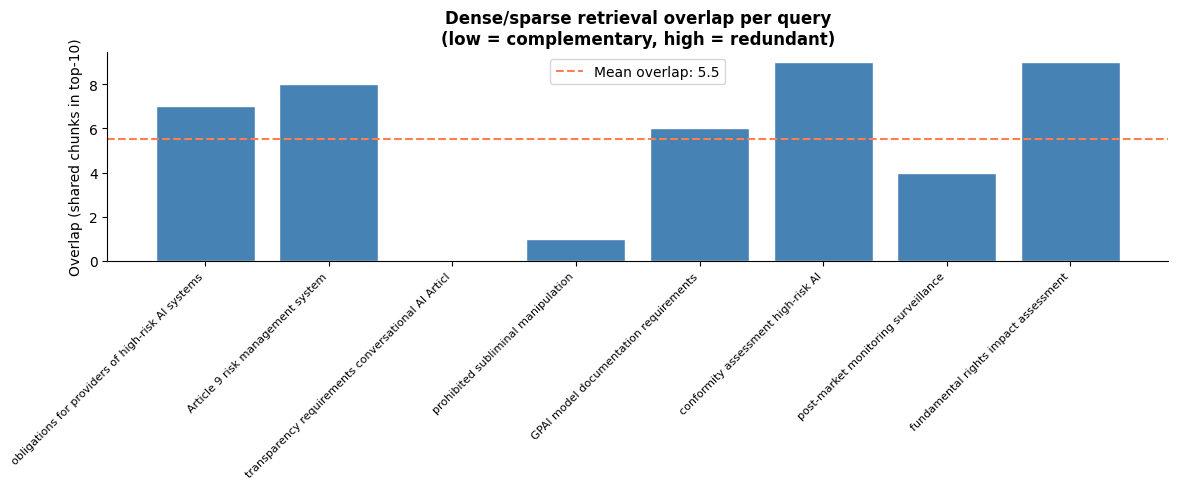

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(overlap_df)), overlap_df['overlap'], color='steelblue', edgecolor='white')
ax.axhline(overlap_df['overlap'].mean(), color='coral', linestyle='--',
           linewidth=1.5, label=f'Mean overlap: {overlap_df["overlap"].mean():.1f}')
ax.set_xticks(range(len(overlap_df)))
ax.set_xticklabels(overlap_df['query'], rotation=45, ha='right', fontsize=8)
ax.set_title('Dense/sparse retrieval overlap per query\n(low = complementary, high = redundant)', fontweight='bold')
ax.set_ylabel('Overlap (shared chunks in top-10)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_03_retrieval_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations for RAGAS test dataset

Based on manual inspection above, note queries where retrieval looks reliable
and queries where it struggles — these feed into notebook 04.

In [14]:
print('RETRIEVAL QUALITY OBSERVATIONS')
print('='*65)
print()
print('✅ WORKS WELL:')
print('  - Semantic obligation queries (dense excels)')
print('  - Exact article references (sparse excels)')
print('  - Hybrid outperforms both on mixed queries')
print('  - Reranking promotes most relevant paragraphs')
print()
print('⚠  AREAS TO WATCH:')
print('  - Short queries may retrieve too broadly')
print('  - Cross-reference chains need agentic resolution')
print('  - GPAI chunks compete with AI Act chunks on GPAI queries')
print()
print('→ RAGAS test set should include:')
print('  - 8 classification queries (Art. 5, 6, Annex III)')
print('  - 8 obligation queries (Art. 9, 10, 13, 17)')
print('  - 4 transparency queries (Art. 50)')
print('  - 4 GPAI queries (Art. 53, 55)')
print('  - 4 cross-reference chains')
print('  = 28 test pairs minimum')

RETRIEVAL QUALITY OBSERVATIONS

✅ WORKS WELL:
  - Semantic obligation queries (dense excels)
  - Exact article references (sparse excels)
  - Hybrid outperforms both on mixed queries
  - Reranking promotes most relevant paragraphs

⚠  AREAS TO WATCH:
  - Short queries may retrieve too broadly
  - Cross-reference chains need agentic resolution
  - GPAI chunks compete with AI Act chunks on GPAI queries

→ RAGAS test set should include:
  - 8 classification queries (Art. 5, 6, Annex III)
  - 8 obligation queries (Art. 9, 10, 13, 17)
  - 4 transparency queries (Art. 50)
  - 4 GPAI queries (Art. 53, 55)
  - 4 cross-reference chains
  = 28 test pairs minimum
